## Long Short Term Memory (Deep learning)

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [2]:
nvidia = pd.read_csv('nvidia_with_features.csv')

In [3]:
nvidia['Target'] = nvidia['Returns'].shift(-1)

In [4]:
nvidia.dropna(inplace=True)

In [5]:
features = [
    'Close',
    'Volume',
    'Returns',
    'MA20',
    'MA50',
    'Volatility',
    'RSI',
    'MACD',
    'Signal_Line',
    'Momentum',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_5',
    'BB_Width'
]

target = 'Target'


In [7]:
train_size = int(len(nvidia) * 0.8)

train_data = nvidia.iloc[:train_size]
test_data = nvidia.iloc[train_size:]

In [9]:
feature_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(
    train_data[features]
)

X_test_scaled = feature_scaler.transform(
    test_data[features]
)

In [10]:
target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    train_data[[target]]
)

y_test_scaled = target_scaler.transform(
    test_data[[target]]
)

In [11]:
import numpy as np

sequence_length = 60

X_train = []
y_train = []

for i in range(sequence_length, len(X_train_scaled)):

    X_train.append(
        X_train_scaled[i-sequence_length:i]
    )

    y_train.append(
        y_train_scaled[i]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

In [12]:
X_test = []
y_test = []

for i in range(sequence_length, len(X_test_scaled)):

    X_test.append(
        X_test_scaled[i-sequence_length:i]
    )

    y_test.append(
        y_test_scaled[i]
    )

X_test = np.array(X_test)
y_test = np.array(y_test)

In [13]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(5334, 60, 15)
(5334, 1)
(1289, 60, 15)
(1289, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

d:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - loss: 0.0081 - val_loss: 0.0989
Epoch 2/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0039 - val_loss: 0.0270
Epoch 3/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0038 - val_loss: 0.0555
Epoch 4/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 0.0036 - val_loss: 0.0321
Epoch 5/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - loss: 0.0033 - val_loss: 0.0251
Epoch 6/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 0.0033 - val_loss: 0.0207
Epoch 7/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0033 - val_loss: 0.0082
Epoch 8/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 0.0033 - val_loss: 0.0078
Epoch 9/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 0.0031 - val_loss: 0.0056
Epoch 10/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0031 - val_loss: 0.0048
Epoch 11/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0030 - val_loss: 0.0070
Epoch 12/150
167/167 ━━━━

In [17]:
predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(
    predictions_scaled
)

actual = target_scaler.inverse_transform(
    y_test
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [22]:
predictions, actual

(array([[0.00509096],
        [0.00497474],
        [0.00506027],
        ...,
        [0.00746691],
        [0.00739231],
        [0.00739064]], shape=(1289, 1), dtype=float32),
 array([[ 0.0121118 ],
        [ 0.00357714],
        [-0.01886911],
        ...,
        [ 0.02948279],
        [ 0.00829145],
        [ 0.01531055]], shape=(1289, 1)))

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

r2 = r2_score(
    actual,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.024241079216087834
RMSE: 0.032952673413217774
R²: -0.02615354671238901


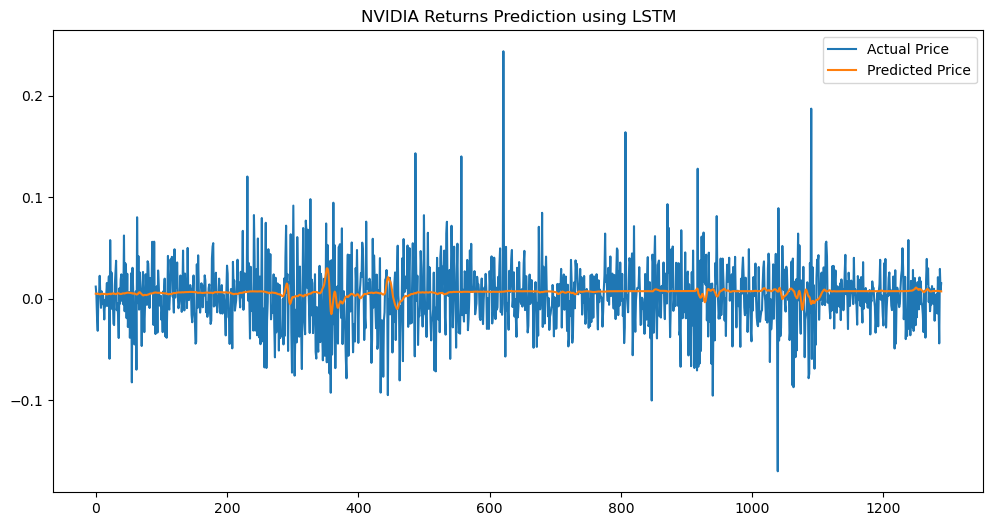

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    actual,
    label='Actual Price'
)

plt.plot(
    predictions,
    label='Predicted Price'
)

plt.legend()

plt.title("NVIDIA Returns Prediction using LSTM")

plt.show()

In [20]:
print(train_data['Target'].min())
print(train_data['Target'].max())

print(test_data['Target'].min())
print(test_data['Target'].max())

-0.3523361651074728
0.4241473611861064
-0.1696816245563553
0.2436963706189707


In [25]:
print(actual.std())
print(predictions.std())

0.032530031131811056
0.003405332


In [26]:
nvidia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6743 entries, 0 to 6742
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          6743 non-null   float64
 1   Volume         6743 non-null   int64  
 2   Returns        6743 non-null   float64
 3   MA20           6743 non-null   float64
 4   MA50           6743 non-null   float64
 5   Volatility     6743 non-null   float64
 6   RSI            6743 non-null   float64
 7   MACD           6743 non-null   float64
 8   Signal_Line    6743 non-null   float64
 9   Momentum       6743 non-null   float64
 10  Lag_1          6743 non-null   float64
 11  Lag_2          6743 non-null   float64
 12  Lag_3          6743 non-null   float64
 13  Lag_5          6743 non-null   float64
 14  Volume_Change  6743 non-null   float64
 15  Volume_MA20    6743 non-null   float64
 16  BB_Width       6743 non-null   float64
 17  Lag_R1         6743 non-null   float64
 18  Lag_R2       